<a href="https://colab.research.google.com/github/akshat-rakheja/RAG-Chatbot-/blob/main/RAG_Chatbot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
# pip install libraries
!pip install sentence-transformers faiss-cpu langchain
!pip install pypdf langchain_community
!pip install langchain-text-splitters

In [47]:
# upload the document
from google.colab import files
uploaded = files.upload()
for filename in uploaded.keys():
  print("uploaded:",filename)

Saving Microsoft 2025 Annual Report.pdf to Microsoft 2025 Annual Report (3).pdf
uploaded: Microsoft 2025 Annual Report (3).pdf


In [48]:
# document ingestion pipeline
from langchain_community.document_loaders import PyPDFLoader
pdf_file = list(uploaded.keys())[0]
loader = PyPDFLoader(pdf_file) # loader object
documents = loader.load()
print("Number of pages loaded",len(documents))


Number of pages loaded 61


In [49]:
print(documents[0])

page_content='HomeShareholder LetterFinancial Review
Directors & OfﬁcersInvestor Relations
Business
Discussion & AnalysisMarket RiskIncome StatementsBalance SheetsCash Flows StatementsStockholders' EquityNotes
Auditor's ReportControls & Procedures
GeneralOperating SegmentsHuman Capital ResourcesOperationsResearch & DevelopmentDistribution, Sales & MarketingLicensing OptionsGovernment RegulationAvailable Information
Accounting PoliciesEarnings Per ShareOther Income (Expense), NetInvestmentsDerivativesProperty and EquipmentBusiness CombinationsGoodwillIntangible AssetsDebtIncome TaxesUnearned RevenueLeasesContingenciesStockholders' EquityAccumulated Other Comprehensive Income (Loss)Employee Stock and Savings PlansSegment Information & Geo Data
Annual Report 2025
Continue to Shareholder Letter
Annual Report 2025
shareholder letter  
05/05/2026, 21:34 Microsoft 2025 Annual Report
https://www.microsoft.com/investor/reports/ar25/index.html 1/61' metadata={'producer': 'Skia/PDF m147', 'creato

In [50]:
# Chunking
from langchain_text_splitters import RecursiveCharacterTextSplitter
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=100)
chunks = text_splitter.split_documents(documents)
print("total chunks created",len(chunks))

total chunks created 702


In [51]:
# Displaying 1 chunk
print(chunks[0].page_content)

HomeShareholder LetterFinancial Review
Directors & OfﬁcersInvestor Relations
Business
Discussion & AnalysisMarket RiskIncome StatementsBalance SheetsCash Flows StatementsStockholders' EquityNotes
Auditor's ReportControls & Procedures
GeneralOperating SegmentsHuman Capital ResourcesOperationsResearch & DevelopmentDistribution, Sales & MarketingLicensing OptionsGovernment RegulationAvailable Information


In [52]:
# embeddings from the chunk
import faiss
import numpy as np
from sentence_transformers import SentenceTransformer

#defining the embedding model
model = SentenceTransformer('all-MiniLM-L6-V2') # 22M parameters only , smaller model

#creating the embeddings
embeddings = model.encode([chunk.page_content for chunk in chunks]) #for each chunks in the chunk

dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(np.array(embeddings))

print("Total vectors in the index ",index.ntotal)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-V2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total vectors in the index  702


In [54]:
print(dimension)

384


In [55]:
import matplotlib.pyplot as plt
def visualize_embedding(vector,chunk_text=None,max_text_chars=500):
  vector = np.array(vector)
  normalized = (vector - vector.min())/(vector.max()-vector.min())
  color_band = normalized.reshape(1,-1)

  if chunk_text is not None:
    print("Chunk text \n")
    print(chunk_text[:max_text_chars])
    print()

    plt.figure(figsize =(12,2))
    plt.imshow(color_band,aspect="auto",cmap="viridis")
    plt.yticks([])
    plt.xlabel(f"Embedding Dimensions ({len(vector)})")
    plt.title("vector representation")
    plt.show()

Chunk text 

Accounting PoliciesEarnings Per ShareOther Income (Expense), NetInvestmentsDerivativesProperty and EquipmentBusiness CombinationsGoodwillIntangible AssetsDebtIncome TaxesUnearned RevenueLeasesContingenciesStockholders' EquityAccumulated Other Comprehensive Income (Loss)Employee Stock and Savings PlansSegment Information & Geo Data
Annual Report 2025
Continue to Shareholder Letter
Annual Report 2025
shareholder letter  
05/05/2026, 21:34 Microsoft 2025 Annual Report



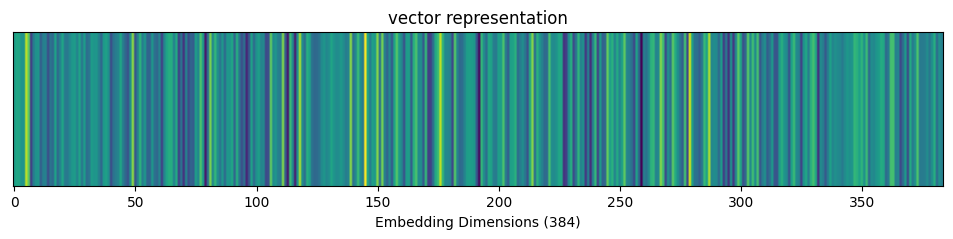

In [56]:
visualize_embedding(embeddings[1],chunks[1].page_content)

Enter your question : tell me about renevue from gaming 
Chunk text 

tell me about renevue from gaming 



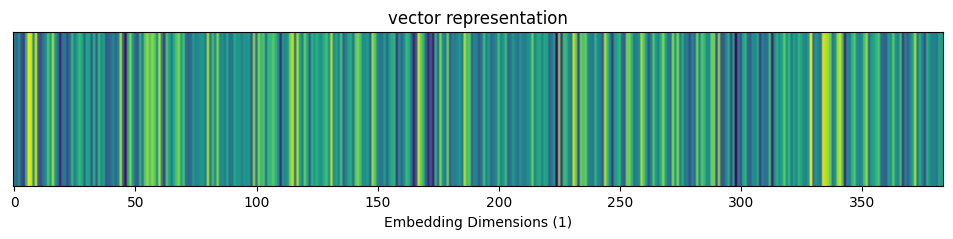

In [57]:
# Retrievel

query = input("Enter your question : ")
query_embedding = model.encode([query])
visualize_embedding(query_embedding,query)

In [58]:
D,I = index.search(np.array(query_embedding),k=5) #looking for 5 similar items
retrieved_chunks = [chunks[i] for i in I[0]]
print("Top retrieved chunks : \n")

for chunk in retrieved_chunks:
  print(chunk.page_content)
  print("Page:",chunk.metadata['page'])
  print("------------------------------------------------")


Top retrieved chunks : 

Gaming
Page: 10
------------------------------------------------
services based on signiﬁcant innovation in hardware architecture, user interface, developer tools, online gaming and entertainmentservices, and continued strong content from our own ﬁrst-party game franchises as well as other digital content offerings.
Page: 11
------------------------------------------------
Microsoft is expanding how billions of people globally access and play video games on PC, console, mobile, and cloud. Our game content isdeveloped through a collection of ﬁrst-party studios creating iconic and differentiated gaming experiences. We continue to invest in gamingstudios and content to expand our intellectual property roadmap and leverage new content creators. These unique gaming experiences are thecornerstone of Xbox Game Pass, a subscription service and gaming community with
Page: 10
------------------------------------------------
a way that is mostconvenient to them. We are fo

In [59]:
# Performing Reranking
from sentence_transformers import CrossEncoder

reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
pairs = [(query,chunk.page_content) for chunk in retrieved_chunks]
scores = reranker.predict(pairs)

ranked_chunks = sorted(zip(scores,retrieved_chunks),
                       key = lambda x:x[0],
                       reverse = True)
print("After reranking :\n")
for score,chunk in ranked_chunks :
  print("score :",score)
  print(chunk.page_content)
  print("Page number :",chunk.metadata["page"])
  print("-------------------------------------------")


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


After reranking :

score : -6.1519785
Gaming
Page number : 10
-------------------------------------------
score : -10.080324
The gamer remains at the heart of the Xbox ecosystem. We are identifying new opportunities to attract gamers across a variety of differentend points through our ﬁrst- and third-party content and business diversiﬁcation across subscriptions, ads, and digital stores. We’ve seen newdevices from third-party manufacturers along with key PC and mobile end points that help us empower gamers to play in a way that is mostconvenient to them. We are focused on growing the platform and expanding to new
Page number : 10
-------------------------------------------
score : -10.510714
Microsoft is expanding how billions of people globally access and play video games on PC, console, mobile, and cloud. Our game content isdeveloped through a collection of ﬁrst-party studios creating iconic and differentiated gaming experiences. We continue to invest in gamingstudios and content to 

In [60]:
# Combine rerank chunks with context
top_chunks = [chunk.page_content for _,chunk in ranked_chunks[:3]]
context = "\n\n".join(top_chunks)
print("Context : \n")
print(context)

Context : 

Gaming

The gamer remains at the heart of the Xbox ecosystem. We are identifying new opportunities to attract gamers across a variety of differentend points through our ﬁrst- and third-party content and business diversiﬁcation across subscriptions, ads, and digital stores. We’ve seen newdevices from third-party manufacturers along with key PC and mobile end points that help us empower gamers to play in a way that is mostconvenient to them. We are focused on growing the platform and expanding to new

Microsoft is expanding how billions of people globally access and play video games on PC, console, mobile, and cloud. Our game content isdeveloped through a collection of ﬁrst-party studios creating iconic and differentiated gaming experiences. We continue to invest in gamingstudios and content to expand our intellectual property roadmap and leverage new content creators. These unique gaming experiences are thecornerstone of Xbox Game Pass, a subscription service and gaming comm

In [61]:
import google.generativeai as genai
from google.colab import userdata

# 1. Configure Gemini API
GEMINI_API_KEY = userdata.get('GeminiAPI_Key')
genai.configure(api_key=GEMINI_API_KEY)

# 2. Initialize the model with the correct preview string
# 'gemini-3-flash-preview' is the current standard for the free tier
model = genai.GenerativeModel('gemini-3-flash-preview')

# 3. Define your RAG logic
def generate_rag_answer(context, query):
    prompt = f"""
    You are a precise assistant. Answer the question using ONLY the provided context.
    If the answer is not contained within the context, state: "Information not found in document."

    Context:
    {context}

    Question:
    {query}

    Answer:
    """

    try:
        response = model.generate_content(prompt)
        return response.text
    except Exception as e:
        return f"An error occurred: {e}"

result = generate_rag_answer(context, query)
print(result)

Information not found in document.


In [62]:
def evaluate_response(query, context, response):
    eval_prompt = f"""
    Evaluate the following RAG response based on the Context.
    Score from 0 to 1 (0 is fail, 1 is perfect).

    1. Faithfulness: Is the answer derived ONLY from the context?
    2. Relevancy: Does the answer actually address the query?

    Query: {query}
    Context: {context}
    Response: {response}

    Return ONLY a JSON: {{"faithfulness": score, "relevancy": score}}
    """
    eval_result = model.generate_content(eval_prompt)
    return eval_result.text



In [63]:
evaluation_result = evaluate_response(query, context, result)
print(evaluation_result)


```json
{"faithfulness": 0, "relevancy": 0}
```
